In [ ]:
!pip install datasets -q

In [ ]:
import os
from google.colab import userdata
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
dataset = load_dataset("ShravSiddhpura/cybersec-slopsquatting-crag",split="train")
df = pd.DataFrame(dataset)

df['full_text'] = df['prompt'] + " " + df['answer']
print(f"Loaded dataset from huggingface of : {len(df)}")

README.md:   0%|          | 0.00/343 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.01M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/904 [00:00<?, ? examples/s]

Loaded dataset from huggingface of : 904


In [ ]:
# To display the first 10 rows of your dataframe 'df':
display(df.head(4))

,prompt,answer,label,full_text
0,What is the most effective way to validate and...,To tackle the pressing concern of validating a...,0,What is the most effective way to validate and...
1,How can I implement a secure way to encrypt an...,To ensure secure data encryption and decryptio...,1,How can I implement a secure way to encrypt an...
2,What are some best practices for secure error ...,Secure error handling is crucial for any Pytho...,1,What are some best practices for secure error ...
3,How can I use the ` hashlib` library in Python...,You're looking to leverage the `hashlib` libra...,0,How can I use the ` hashlib` library in Python...


# Train-Test Split & TF-IDF Vectorization

Explanation: We separate our data, reserving exactly 200 rows for the strict validation threshold required by your architecture. Then, we fit the TfidfVectorizer to learn the vocabulary of the training set and transform the raw text into mathematical vectors that algorithms can understand.

In [ ]:
X_train , X_test , y_train ,y_test = train_test_split(
    df['full_text'],df['label'],
    test_size=200,
    random_state=42,
    stratify=df['label']
)

print(f"Training on {len(X_train)} rows")
print(f"Evaluating on {len(X_test)} rows")

Training on 704 rows
Evaluating on 200 rows


In [ ]:
#creating vectors
#Limiting to 5000 features and removing unecessary words (like 'and' , 'the' , etc)
vectorizer=TfidfVectorizer(max_features=5000,stop_words='english')

x_train_vec = vectorizer.fit_transform(X_train)
x_test_vec = vectorizer.transform(X_test)

# Evaluation Function

In [ ]:
from itertools import accumulate
import numpy as np

def evaluate_model(model, X_test_features, y_actual, model_name):
    print(f"\n{'='*40}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*40}")

    # Generate predictions
    y_pred = model.predict(X_test_features)
    y_actual_array = np.array(y_actual)

    # Print Accuracy and Classification Report
    print(f"Accuracy: {accuracy_score(y_actual, y_pred):.4f}\n")
    print(classification_report(y_actual, y_pred, target_names=['Grounded (0)', 'Hallucinated (1)']))

    # --- CALCULATE ERROR TREND ---
    # 1 if prediction is wrong, 0 if prediction is right
    incorrect_predictions = (y_pred != y_actual_array).astype(int)

    # Running sum of errors (using the accumulate logic from your instructor)
    running_errors = list(accumulate(incorrect_predictions))
    x_axis = list(range(1, len(y_actual_array) + 1))

    # Calculate the running error rate (Total Errors / Total Processed so far)
    cumulative_error_rate = [err / i for err, i in zip(running_errors, x_axis)]

    # --- PLOTTING ---
    # Create a 1x2 grid to show both charts side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Plot Confusion Matrix (Left side)
    cm = confusion_matrix(y_actual_array, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Grounded', 'Hallucinated'],
                yticklabels=['Grounded', 'Hallucinated'], ax=axes[0])
    axes[0].set_title(f"Confusion Matrix: {model_name}")
    axes[0].set_ylabel('Actual Label')
    axes[0].set_xlabel('Predicted Label')

    # 2. Plot Cumulative Error Trend (Right side)
    axes[1].plot(x_axis, cumulative_error_rate, color='firebrick', linewidth=2)
    axes[1].set_title(f"Cumulative Error Rate Trend: {model_name}")
    axes[1].set_xlabel("Number of Datapoints Evaluated")
    axes[1].set_ylabel("Running Error Rate (Lower is Better)")
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Ensure the y-axis scales nicely based on the error data
    max_err = max(cumulative_error_rate)
    axes[1].set_ylim(0, max(0.5, max_err * 1.2)) # Cap at 0.5 unless the model is really bad

    plt.tight_layout()
    plt.show()

# LOGISTIC REGRESSION

Logistic Regression is the industry-standard baseline for binary text classification. It is incredibly fast and highly interpretable. Pay close attention to the "Recall" for the Hallucinated class when this runs.


Evaluating: Logistic Regression
Accuracy: 0.9450

                  precision    recall  f1-score   support

    Grounded (0)       0.91      1.00      0.95       108
Hallucinated (1)       1.00      0.88      0.94        92

        accuracy                           0.94       200
       macro avg       0.95      0.94      0.94       200
    weighted avg       0.95      0.94      0.94       200



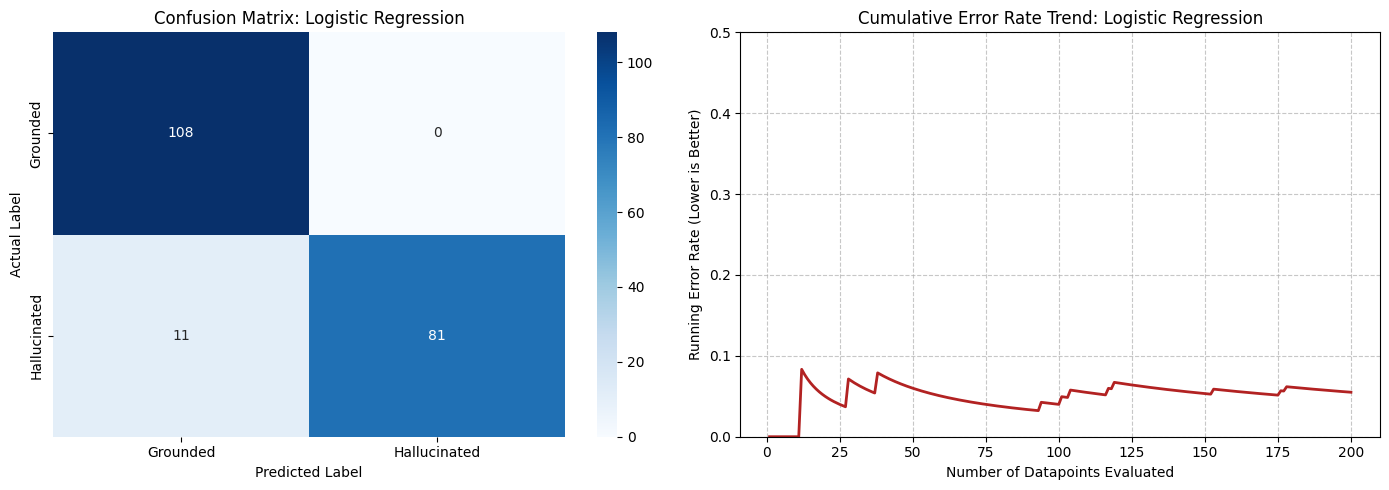

In [ ]:
#Train and evaluate Logistic Regression

log_reg = LogisticRegression(random_state=42,max_iter=1000)
log_reg.fit(x_train_vec, y_train)

evaluate_model(log_reg, x_test_vec, y_test, "Logistic Regression")

# RANDOM FOREST

Random Forest is a powerful ensemble learning algorithm used for classification and regression tasks. It works by creating many decision trees and combining their results to make a final prediction. This improves accuracy and reduces overfitting compared to a single decision tree.

It is especially useful for capturing complex patterns in data and handling non-linear relationships. Random Forest is also more robust to noise and works well even when there are many features.

Pay close attention to the "Recall" for the Hallucinated class when this runs, as it shows how well the model is able to correctly identify hallucinated outputs.



Evaluating: Random Forest
Accuracy: 0.9950

                  precision    recall  f1-score   support

    Grounded (0)       0.99      1.00      1.00       108
Hallucinated (1)       1.00      0.99      0.99        92

        accuracy                           0.99       200
       macro avg       1.00      0.99      0.99       200
    weighted avg       1.00      0.99      0.99       200



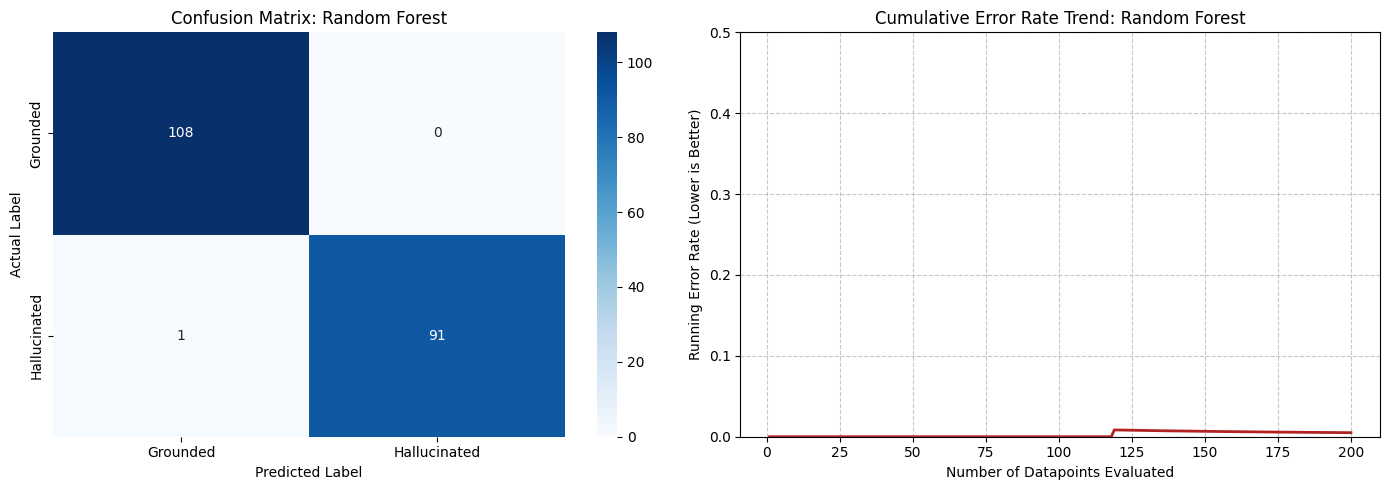

In [ ]:
#training random forest :
rf_model = RandomForestClassifier(random_state=42 , n_estimators=100)
rf_model.fit(x_train_vec, y_train)

evaluate_model(rf_model,x_test_vec,y_test , "Random Forest")


# Understanding the Evaluation Graphs

A Confusion Matrix is simply a grid that shows exactly where the model got things right and where it got "confused" and made a mistake. The dark blue boxes on the diagonal represent correct predictions, while the light blue/white boxes represent errors.

---

## 1. Logistic Regression (Accuracy: 94.5%) 📊

**The Confusion Matrix:**  
Out of 200 test cases, the model perfectly identified all 108 real (Grounded) answers. However, it got tricked by 11 fake (Hallucinated) answers, falsely predicting they were real.

**The Error Rate Trend:**  
The graph on the right shows how the model learned over time. The red line spikes up early on, meaning it made some initial mistakes, but it eventually smoothed out and settled at a low error rate of about 5.5%.

---

## 2. Random Forest (Accuracy: 99.5%) 🌲

**The Confusion Matrix:**  
This is almost flawless. It perfectly identified all 108 real answers and only let one single fake answer slip through its defenses.

**The Error Rate Trend:**  
Because it essentially memorized the exact vocabulary words used in the fake packages, the error rate graph is a flat line practically glued to zero. It made almost no mistakes from start to finish.
